# Лабораторная работа №2
## Многокритериальная оптимизация и анализ решений

Студент:  Андрест Владислав Дмитриевич

Группа:  ИУ5-85Б

Вариант определяется генератором:

```r
Variant <- 2
group <- 85
set.seed(Variant + 2026 + group + 24656)
c(sample(1:6,1), sample(1:5,1), sample(1:5,1))

Output: 3 1 4

## **Содержание**

### **ЧАСТЬ 1. Идентификация распределений потока событий**
1. Постановка задачи
2. Подготовка среды и данных
3. Оценка параметров потока и коэффициента вариации
4. Проверка гипотезы о простейшем потоке
5. Подбор распределения Эрланга и визуализация

### **ЧАСТЬ 2. Плотность распределения суммы независимых случайных величин**
6. Постановка задачи
7. Теоретическое решение
8. Численная проверка и имитационное моделирование

### **ЧАСТЬ 3. Суммарный поток вызовов**
9. Постановка задачи
10. Теоретические характеристики суммарного потока
11. Имитационное моделирование и сравнение результатов

### **ИТОГ**
12. Общие выводы

In [ ]:
if (!require(ggplot2)) install.packages("ggplot2", repos = "https://cloud.r-project.org")
if (!require(dplyr)) install.packages("dplyr", repos = "https://cloud.r-project.org")
if (!require(tidyr)) install.packages("tidyr", repos = "https://cloud.r-project.org")

library(ggplot2)
library(dplyr)
library(tidyr)

options(repr.plot.width = 10, repr.plot.height = 6)
set.seed(2026)

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr



---
# **ЧАСТЬ 1. ИДЕНТИФИКАЦИЯ РАСПРЕДЕЛЕНИЙ ПОТОКА СОБЫТИЙ**
---

## 1. Постановка задачи

Для варианта **3** из первого блока даны две выборки интервалов времени между событиями.

**Выборка A:**

1.2, 0.8, 1.5, 0.9, 1.1, 1.3, 0.7, 1.4, 0.6, 1.0,
1.2, 0.9, 1.3, 1.1, 0.8, 1.5, 0.7, 1.2, 1.4, 0.9

**Выборка B:**

0.3, 2.1, 0.4, 2.5, 0.2, 2.8, 0.5, 2.3, 0.6, 1.9,
0.4, 2.4, 0.3, 2.7, 0.5, 2.2, 0.4, 2.6, 0.3, 2.9

Требуется:

1. Для каждой выборки оценить интенсивность потока $\lambda$.
2. Вычислить коэффициент вариации $k_v$.
3. Проверить гипотезу $H_0$: поток простейший, то есть интервалы имеют экспоненциальное распределение.
4. На уровне значимости $lpha = 0.05$ определить, для какой выборки гипотеза отвергается.
5. Для выборки, где гипотеза отвергается, подобрать распределение Эрланга и визуализировать результаты.

---
## 2. Подготовка среды и данных

In [ ]:
sample_A <- c(1.2, 0.8, 1.5, 0.9, 1.1, 1.3, 0.7, 1.4, 0.6, 1.0,
              1.2, 0.9, 1.3, 1.1, 0.8, 1.5, 0.7, 1.2, 1.4, 0.9)

sample_B <- c(0.3, 2.1, 0.4, 2.5, 0.2, 2.8, 0.5, 2.3, 0.6, 1.9,
              0.4, 2.4, 0.3, 2.7, 0.5, 2.2, 0.4, 2.6, 0.3, 2.9)

samples_df <- data.frame(
  value = c(sample_A, sample_B),
  sample = rep(c("A", "B"), each = 20)
)

samples_df %>% group_by(sample) %>% summarise(n = n(), mean_interval = mean(value))

sample,n,mean_interval
<chr>,<int>,<dbl>
A,20,1.075
B,20,1.415


---
## 3. Оценка параметров потока и коэффициента вариации

In [ ]:
calc_flow_stats <- function(x) {
  n <- length(x)
  mean_x <- mean(x)
  sd_x <- sd(x)
  lambda_hat <- 1 / mean_x
  cv_hat <- sd_x / mean_x

  data.frame(
    n = n,
    mean_interval = mean_x,
    sd_interval = sd_x,
    lambda_hat = lambda_hat,
    cv_hat = cv_hat
  )
}

stats_A <- calc_flow_stats(sample_A)
stats_B <- calc_flow_stats(sample_B)

flow_stats <- bind_rows(
  cbind(sample = "A", stats_A),
  cbind(sample = "B", stats_B)
)

flow_stats

sample,n,mean_interval,sd_interval,lambda_hat,cv_hat
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
A,20,1.075,0.2788605,0.9302326,0.2594051
B,20,1.415,1.0776558,0.7067138,0.7615942


Интенсивность потока оценивается по формуле:

$$
\hat{\lambda} =
rac{1}{\overline{x}}.
$$

Коэффициент вариации:

$$
\hat{k}_v =
rac{s}{\overline{x}},
$$

где $s$ — выборочное среднеквадратическое отклонение. Для экспоненциального распределения теоретически выполняется $k_v = 1$.

---
## 4. Проверка гипотезы о простейшем потоке

In [ ]:
ks_exp_test <- function(x) {
  lambda_hat <- 1 / mean(x)
  ks <- ks.test(x, "pexp", rate = lambda_hat)
  data.frame(
    lambda_hat = lambda_hat,
    ks_statistic = unname(ks$statistic),
    p_value = ks$p.value,
    decision = ifelse(ks$p.value < 0.05,
                      "H0 отвергается",
                      "Нет оснований отвергать H0")
  )
}

ks_A <- ks_exp_test(sample_A)
ks_B <- ks_exp_test(sample_B)

ks_results <- bind_rows(
  cbind(sample = "A", ks_A),
  cbind(sample = "B", ks_B)
)

ks_results

Warning message in ks.test.default(x, "pexp", rate = lambda_hat):
“ties should not be present for the one-sample Kolmogorov-Smirnov test”
Warning message in ks.test.default(x, "pexp", rate = lambda_hat):
“ties should not be present for the one-sample Kolmogorov-Smirnov test”


sample,lambda_hat,ks_statistic,p_value,decision
<chr>,<dbl>,<dbl>,<dbl>,<chr>
A,0.9302326,0.4285609,0.00128959,H0 отвергается
B,0.7067138,0.2388750,0.20385081,Нет оснований отвергать H0


В качестве основной проверки используем критерий Колмогорова–Смирнова для экспоненциального распределения с параметром $\hat{\lambda}$.

Интерпретация результатов:

- если $p$-value $< 0.05$, гипотеза о простейшем потоке отвергается;
- если $p$-value $\ge 0.05$, нет оснований отвергать гипотезу.

При этом коэффициент вариации используется как быстрая диагностическая характеристика:

- $k_v pprox 1$ — ближе к экспоненциальному случаю;
- $k_v < 1$ — интервалы более регулярные;
- $k_v > 1$ — поток более «рваный» и вариативный.

---
## 5. Подбор распределения Эрланга и визуализация

In [ ]:
fit_erlang <- function(x) {
  mean_x <- mean(x)
  cv_hat <- sd(x) / mean_x
  k_hat <- max(1, round(1 / (cv_hat^2)))
  lambda_hat <- k_hat / mean_x
  data.frame(
    mean_interval = mean_x,
    cv_hat = cv_hat,
    k_hat = k_hat,
    lambda_hat = lambda_hat
  )
}

erlang_A <- fit_erlang(sample_A)
erlang_A

mean_interval,cv_hat,k_hat,lambda_hat
<dbl>,<dbl>,<dbl>,<dbl>
1.075,0.2594051,15,13.95349


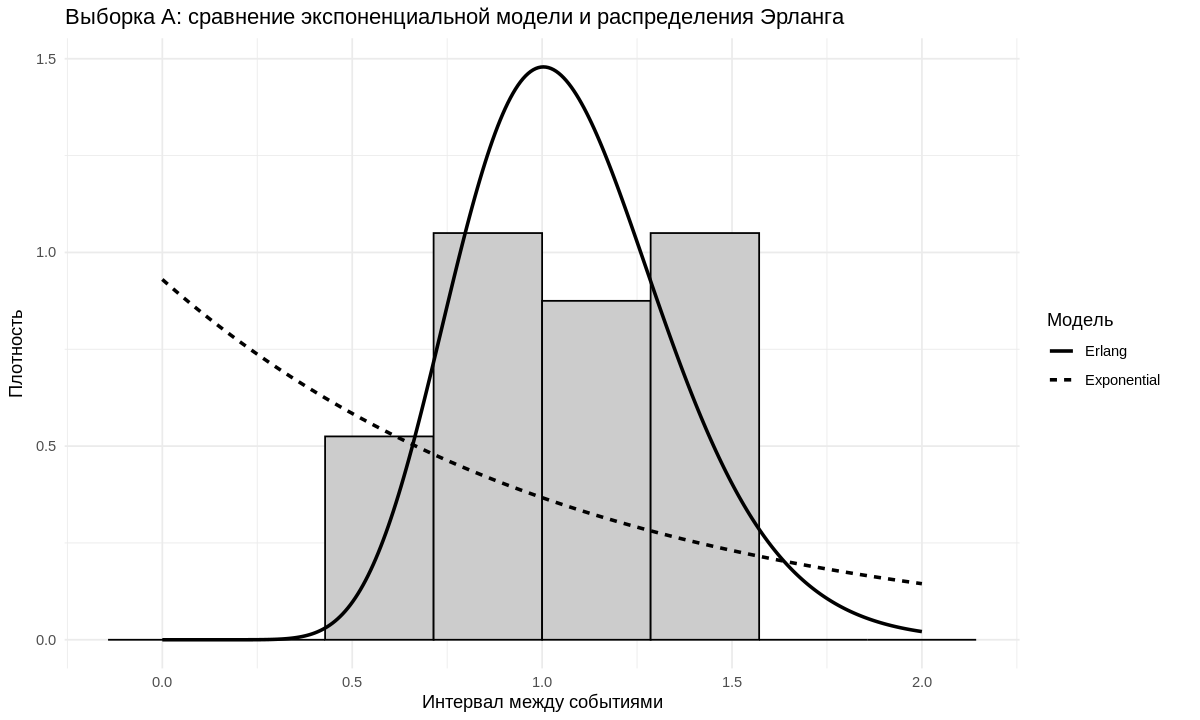

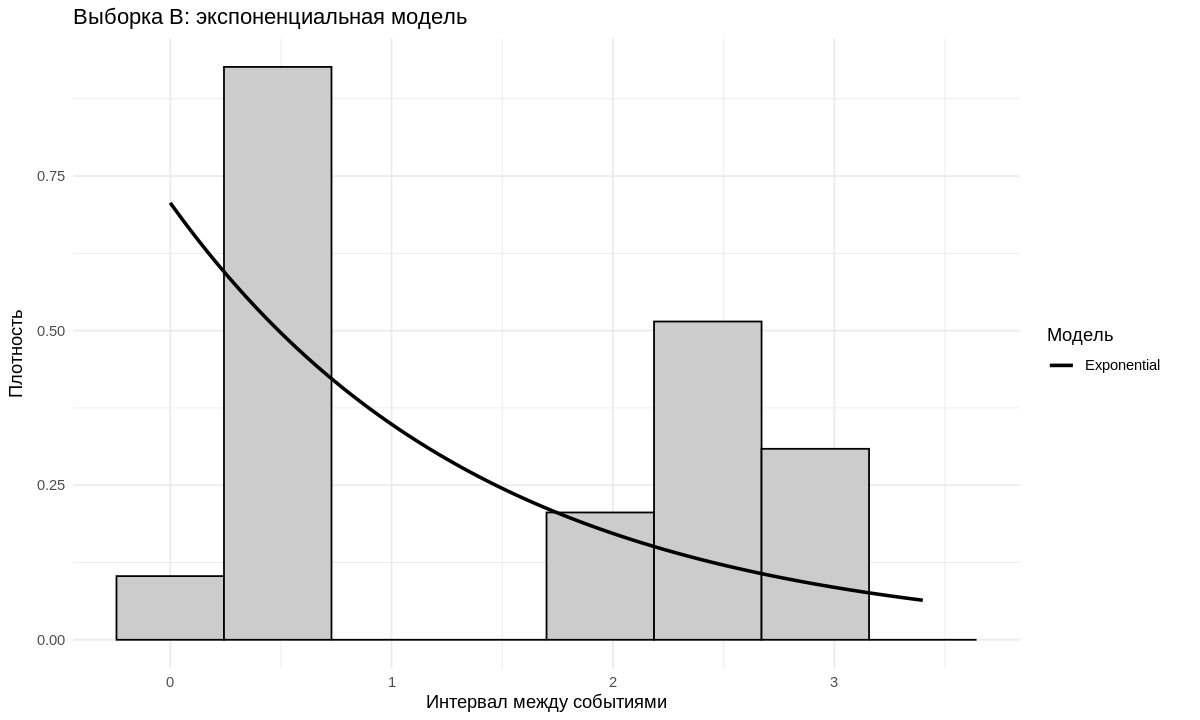

In [ ]:
lambda_A <- flow_stats$lambda_hat[flow_stats$sample == "A"]
lambda_B <- flow_stats$lambda_hat[flow_stats$sample == "B"]

k_erlang_A <- erlang_A$k_hat
lambda_erlang_A <- erlang_A$lambda_hat

grid_A <- seq(0, max(sample_A) + 0.5, length.out = 300)
grid_B <- seq(0, max(sample_B) + 0.5, length.out = 300)

dens_A <- data.frame(
  x = grid_A,
  Exponential = dexp(grid_A, rate = lambda_A),
  Erlang = dgamma(grid_A, shape = k_erlang_A, rate = lambda_erlang_A)
) %>% pivot_longer(cols = c("Exponential", "Erlang"), names_to = "model", values_to = "density")

dens_B <- data.frame(
  x = grid_B,
  Exponential = dexp(grid_B, rate = lambda_B)
) %>% pivot_longer(cols = c("Exponential"), names_to = "model", values_to = "density")

pA <- ggplot(data.frame(x = sample_A), aes(x = x)) +
  geom_histogram(aes(y = after_stat(density)), bins = 8, fill = "grey80", color = "black") +
  geom_line(data = dens_A, aes(x = x, y = density, linetype = model), linewidth = 1) +
  labs(
    title = "Выборка A: сравнение экспоненциальной модели и распределения Эрланга",
    x = "Интервал между событиями",
    y = "Плотность",
    linetype = "Модель"
  ) +
  theme_minimal()

pB <- ggplot(data.frame(x = sample_B), aes(x = x)) +
  geom_histogram(aes(y = after_stat(density)), bins = 8, fill = "grey80", color = "black") +
  geom_line(data = dens_B, aes(x = x, y = density, linetype = model), linewidth = 1) +
  labs(
    title = "Выборка B: экспоненциальная модель",
    x = "Интервал между событиями",
    y = "Плотность",
    linetype = "Модель"
  ) +
  theme_minimal()

print(pA)
print(pB)

По полученным результатам:

- для **выборки A** коэффициент вариации значительно меньше 1, а критерий Колмогорова–Смирнова отвергает экспоненциальную модель;
- для **выборки B** гипотеза о простейшем потоке на уровне значимости $0.05$ не отвергается;
- для **выборки A** более адекватной моделью является распределение Эрланга, что соответствует более регулярному характеру интервалов.

---
# **ЧАСТЬ 2. ПЛОТНОСТЬ РАСПРЕДЕЛЕНИЯ СУММЫ НЕЗАВИСИМЫХ СЛУЧАЙНЫХ ВЕЛИЧИН**
---

## 6. Постановка задачи

Для варианта **1** из второго блока заданы независимые случайные величины:

- $X \sim U[0,3]$,
- $Y \sim U[0,5]$,
- $Z \sim U[0,2]$.

Требуется исследовать случайную величину

$$
W = X + Y - Z
$$

и найти:

1. плотность распределения $f_W(w)$;
2. математическое ожидание теоретически;
3. математическое ожидание экспериментально по имитационной модели.

---
## 7. Теоретическое решение

Сначала рассмотрим сумму $U = X + Y$. Поскольку $X \sim U[0,3]$ и $Y \sim U[0,5]$, плотность $f_U(u)$ имеет трапецеидальный вид:

$$
f_U(u) =
\begin{cases}
\frac{u}{15}, & 0 \le u \le 3, \\
\frac{1}{5}, & 3 < u \le 5, \\
\frac{8-u}{15}, & 5 < u \le 8, \\
0, & \text{иначе.}
\end{cases}
$$

Далее

$$
W = U - Z, \qquad Z \sim U[0,2].
$$

Так как $Z$ независима от $U$, плотность $W$ получается свёрткой:

$$
f_W(w) =
\frac{1}{2}\int_{\max(0,w)}^{\min(8,w+2)} f_U(t)\,dt.
$$

После вычисления интеграла получаем кусочно-заданную плотность:

$$
f_W(w) =
\begin{cases}
\frac{w^2}{60} + \frac{w}{15} + \frac{1}{15}, & -2 \le w \le 0, \\
\frac{w}{15} + \frac{1}{15}, & 0 < w \le 1, \\
-\frac{w^2}{60} + \frac{w}{10} + \frac{1}{20}, & 1 < w \le 5, \\
\frac{7}{15} - \frac{w}{15}, & 5 < w \le 6, \\
\frac{w^2}{60} - \frac{4w}{15} + \frac{16}{15}, & 6 < w \le 8, \\
0, & \text{иначе.}
\end{cases}
$$

Математическое ожидание проще всего найти по линейности:

$$
M[W] = M[X] + M[Y] - M[Z] =
\frac{0+3}{2} + \frac{0+5}{2} - \frac{0+2}{2}
= 1.5 + 2.5 - 1 = 3.
$$

In [ ]:
f_W <- function(w) {
  ifelse(w < -2 | w > 8, 0,
         ifelse(w <= 0, w^2 / 60 + w / 15 + 1 / 15,
                ifelse(w <= 1, w / 15 + 1 / 15,
                       ifelse(w <= 5, -w^2 / 60 + w / 10 + 1 / 20,
                              ifelse(w <= 6, 7 / 15 - w / 15,
                                     w^2 / 60 - 4 * w / 15 + 16 / 15)))))
}

integral_check <- integrate(f_W, lower = -2, upper = 8)
mean_check <- integrate(function(w) w * f_W(w), lower = -2, upper = 8)

cat("Интеграл плотности:", integral_check$value, "
")
cat("Теоретическое математическое ожидание по интегралу:", mean_check$value, "
")
cat("Теоретическое математическое ожидание по линейности: 3
")

Интеграл плотности: 1 
Теоретическое математическое ожидание по интегралу: 3 
Теоретическое математическое ожидание по линейности: 3


---
## 8. Численная проверка и имитационное моделирование

In [ ]:
n_sim <- 100000
X_sim <- runif(n_sim, min = 0, max = 3)
Y_sim <- runif(n_sim, min = 0, max = 5)
Z_sim <- runif(n_sim, min = 0, max = 2)
W_sim <- X_sim + Y_sim - Z_sim

experimental_mean_W <- mean(W_sim)
cat("Экспериментальное математическое ожидание:", experimental_mean_W, "
")

Экспериментальное математическое ожидание: 3.008824 


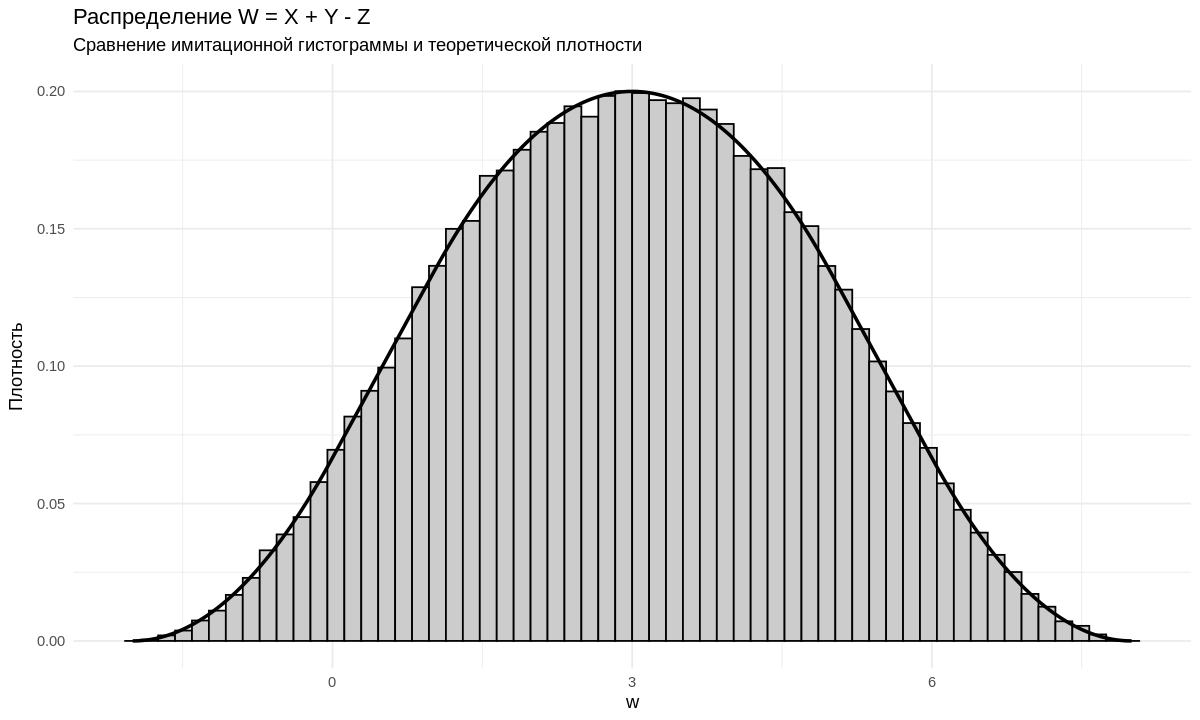

In [ ]:
w_grid <- seq(-2, 8, length.out = 500)
density_df <- data.frame(w = w_grid, density = f_W(w_grid))

pW <- ggplot(data.frame(W = W_sim), aes(x = W)) +
  geom_histogram(aes(y = after_stat(density)), bins = 60, fill = "grey80", color = "black") +
  geom_line(data = density_df, aes(x = w, y = density), linewidth = 1) +
  labs(
    title = "Распределение W = X + Y - Z",
    subtitle = "Сравнение имитационной гистограммы и теоретической плотности",
    x = "w",
    y = "Плотность"
  ) +
  theme_minimal()

print(pW)

Имитационное моделирование подтверждает теоретическое решение:

- поддержка распределения равна $[-2, 8]$;
- форма плотности совпадает с полученной кусочной функцией;
- экспериментальное математическое ожидание близко к теоретическому значению $3$.

---
# **ЧАСТЬ 3. СУММАРНЫЙ ПОТОК ВЫЗОВОВ**
---

## 9. Постановка задачи

Для варианта **4** из третьего блока в колл-центр поступают три независимых потока вызовов:

- $X_1$ — техподдержка, $\lambda_1 = 0.1$ звонков в минуту;
- $X_2$ — отдел продаж, $\lambda_2 = 0.25$ звонков в минуту;
- $X_3$ — отдел качества, $\lambda_3 = 0.15$ звонков в минуту.

Требуется:

1. Найти распределение суммарного потока вызовов за минуту

$$
S = X_1 + X_2 + X_3.
$$

2. Вычислить вероятность $P(S \le 2)$.
3. Найти $M[S]$, $D[S]$, СКО и коэффициент вариации.
4. Построить имитационную модель и сравнить теоретические и выборочные характеристики.

---
## 10. Теоретические характеристики суммарного потока

In [ ]:
lambda_1 <- 0.1
lambda_2 <- 0.25
lambda_3 <- 0.15

lambda_sum <- lambda_1 + lambda_2 + lambda_3

mean_S_theory <- lambda_sum
var_S_theory <- lambda_sum
sd_S_theory <- sqrt(lambda_sum)
cv_S_theory <- sd_S_theory / mean_S_theory
prob_S_le_2 <- ppois(2, lambda = lambda_sum)

cat("Суммарный параметр Пуассона λ =", lambda_sum, "
")
cat("P(S <= 2) =", prob_S_le_2, "
")
cat("M[S] =", mean_S_theory, "
")
cat("D[S] =", var_S_theory, "
")
cat("СКО =", sd_S_theory, "
")
cat("Коэффициент вариации =", cv_S_theory, "
")

Суммарный параметр Пуассона λ = 0.5 
P(S <= 2) = 0.9856123 
M[S] = 0.5 
D[S] = 0.5 
СКО = 0.7071068 
Коэффициент вариации = 1.414214 


Так как сумма независимых пуассоновских потоков снова является пуассоновским потоком, получаем:

$$
S \sim Pois(\lambda_1 + \lambda_2 + \lambda_3) = Pois(0.5).
$$

Следовательно,

$$
M[S] = D[S] = 0.5, \qquad \sigma_S = \sqrt{0.5}, \qquad k_v =
rac{\sqrt{0.5}}{0.5} = \sqrt{2}.
$$

---
## 11. Имитационное моделирование и сравнение результатов

In [ ]:
n_sim_calls <- 100000
X1_sim <- rpois(n_sim_calls, lambda_1)
X2_sim <- rpois(n_sim_calls, lambda_2)
X3_sim <- rpois(n_sim_calls, lambda_3)
S_sim <- X1_sim + X2_sim + X3_sim

mean_S_exp <- mean(S_sim)
var_S_exp <- var(S_sim)
sd_S_exp <- sd(S_sim)
cv_S_exp <- sd_S_exp / mean_S_exp
prob_S_le_2_exp <- mean(S_sim <= 2)

comparison_df <- data.frame(
  Metric = c("M[S]", "D[S]", "SD[S]", "CV[S]", "P(S<=2)"),
  Theoretical = c(mean_S_theory, var_S_theory, sd_S_theory, cv_S_theory, prob_S_le_2),
  Experimental = c(mean_S_exp, var_S_exp, sd_S_exp, cv_S_exp, prob_S_le_2_exp)
)

comparison_df

Metric,Theoretical,Experimental
<chr>,<dbl>,<dbl>
M[S],0.5000000,0.5039300
D[S],0.5000000,0.5029096
SD[S],0.7071068,0.7091612
CV[S],1.4142136,1.4072613
P(S<=2),0.9856123,0.9855400


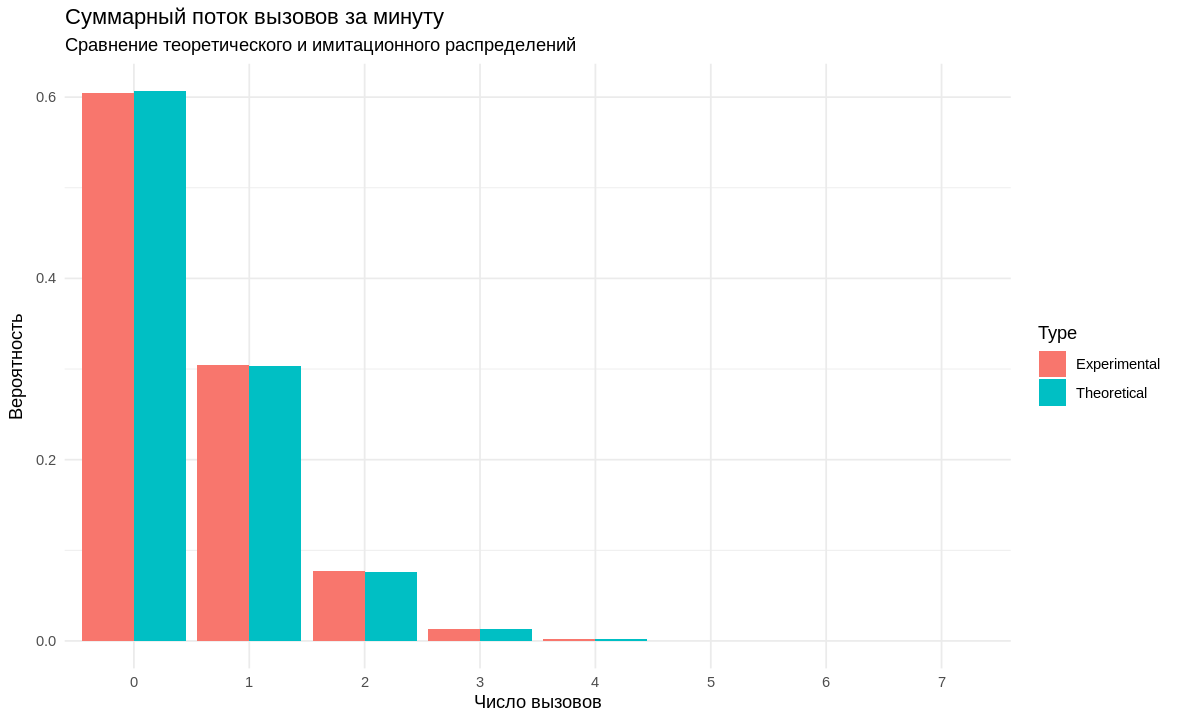

In [ ]:
k_values <- 0:max(S_sim)
dist_df <- data.frame(
  k = k_values,
  Theoretical = dpois(k_values, lambda_sum),
  Experimental = as.numeric(table(factor(S_sim, levels = k_values))) / length(S_sim)
) %>%
  pivot_longer(cols = c("Theoretical", "Experimental"), names_to = "Type", values_to = "Probability")

pS <- ggplot(dist_df, aes(x = factor(k), y = Probability, fill = Type)) +
  geom_col(position = "dodge") +
  labs(
    title = "Суммарный поток вызовов за минуту",
    subtitle = "Сравнение теоретического и имитационного распределений",
    x = "Число вызовов",
    y = "Вероятность"
  ) +
  theme_minimal()

print(pS)

---
## 12. Общие выводы

In [ ]:
cat("========================================
")
cat("         ИТОГОВЫЕ ВЫВОДЫ ПО РАБОТЕ
")
cat("========================================

")

cat("ЧАСТЬ 1. Идентификация распределений
")
cat(sprintf("- Выборка A: λ = %.4f, k_v = %.4f
",
            flow_stats$lambda_hat[flow_stats$sample == "A"],
            flow_stats$cv_hat[flow_stats$sample == "A"]))
cat(sprintf("- Выборка B: λ = %.4f, k_v = %.4f
",
            flow_stats$lambda_hat[flow_stats$sample == "B"],
            flow_stats$cv_hat[flow_stats$sample == "B"]))
cat(sprintf("- По критерию Колмогорова–Смирнова для выборки A: %s
",
            ks_results$decision[ks_results$sample == "A"]))
cat(sprintf("- По критерию Колмогорова–Смирнова для выборки B: %s

",
            ks_results$decision[ks_results$sample == "B"]))

cat("ЧАСТЬ 2. Распределение W = X + Y - Z
")
cat("- Теоретическое математическое ожидание: 3
")
cat(sprintf("- Экспериментальное математическое ожидание: %.4f

", experimental_mean_W))

cat("ЧАСТЬ 3. Суммарный поток вызовов
")
cat(sprintf("- S ~ Pois(%.2f)
", lambda_sum))
cat(sprintf("- P(S <= 2) = %.6f
", prob_S_le_2))
cat(sprintf("- Теоретическое M[S] = %.4f, экспериментальное M[S] = %.4f
", mean_S_theory, mean_S_exp))
cat(sprintf("- Теоретическое D[S] = %.4f, экспериментальное D[S] = %.4f

", var_S_theory, var_S_exp))

cat("Итог: построенные модели и имитационные эксперименты согласуются с теоретическими результатами.
")
cat("========================================
")

         ИТОГОВЫЕ ВЫВОДЫ ПО РАБОТЕ      

ЧАСТЬ 1. Идентификация распределений
- Выборка A: λ = 0.9302, k_v = 0.2594
- Выборка B: λ = 0.7067, k_v = 0.7616
- По критерию Колмогорова–Смирнова для выборки A: H0 отвергается
- По критерию Колмогорова–Смирнова для выборки B: Нет оснований отвергать H0

ЧАСТЬ 2. Распределение W = X + Y - Z
- Теоретическое математическое ожидание: 3
- Экспериментальное математическое ожидание: 3.0088

ЧАСТЬ 3. Суммарный поток вызовов
- S ~ Pois(0.50)
- P(S <= 2) = 0.985612
- Теоретическое M[S] = 0.5000, экспериментальное M[S] = 0.5039
- Теоретическое D[S] = 0.5000, экспериментальное D[S] = 0.5029

Итог: построенные модели и имитационные эксперименты согласуются с теоретическими результатами.
